# Markov Chain Comparison
In this file, we use data of trajectories of choanoflagelates confined in a 2D plan before and after addition of different substances:
- **RS39604** is a synthetic agonist that activates our ion channel.
- **15M9E** is a natural product purified from bacteria that also activates the channel.
- **Algoriphagus** machipongonensis is the bacterium from which 15M9E was purified, and a natural prey source for this choanoflagellate species.

The notebook is organized as follow:
1. Import and convert the data.
2. Make the embedding.
3. Clusterize all the data togethers and Make the Markov chains
4. Compare the Markov Chains.


# Import the xml files and convert xml into dataframes

In [1]:
import sys
sys.path.append('../../src')
sys.path.append('../..')
from xml_df_parser import trackmate_xml_to_df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm 
colors = cm.Reds(np.linspace(0.4, 0.9, 10))  # Gradient from light to dark red
import awkward as ak
import src.viz
from matplotlib.colors import Normalize, LogNorm
import h5py
import pickle


/home/hugo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
folder = "../../data/Algoriphagus/"
xml_files = ["Expt1_251217_Pre", "Expt1_251217_Post"]
ext = ".xml"
dfs = list()
for file in xml_files:
    dfs.append(trackmate_xml_to_df(folder+file+ext))


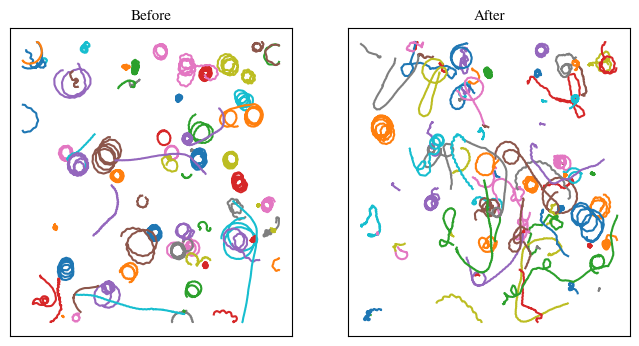

In [8]:
fig,ax = plt.subplots(ncols=len(dfs),figsize=(4*len(dfs),4))
titles = ["Before","After"]
for i in range(len(dfs)):
    for id,track in dfs[i].groupby('Track_ID'):
        ax[i].plot(track['X'],-track['Y'])
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(titles[i])
fig.savefig('exp_algoriphagus.svg',transparent=True)


     Spot_ID  Track_ID  Frame           X            Y    Z
0       2178         0      0  400.400844  1634.425105  0.0
69      2483         0      1  399.938974  1629.545128  0.0
124     2627         0      2  399.417460  1626.611111  0.0
157     2696         0      3  399.428875  1624.386412  0.0
213     2582         0      4  399.416402  1622.438624  0.0


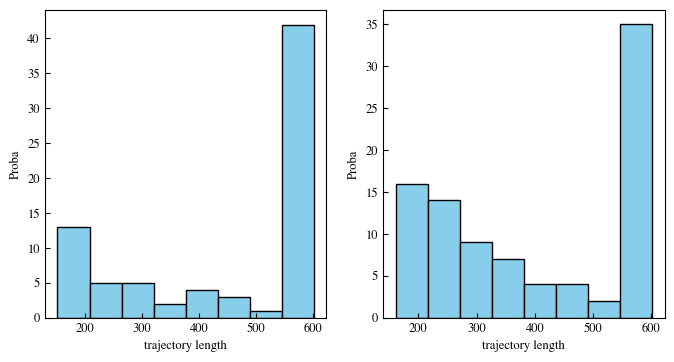

In [4]:
print(dfs[0].head())
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
for i,df in enumerate(dfs):
    traj_lengths = df.groupby('Track_ID').size()
    ax[i].hist(traj_lengths, bins='auto', color='skyblue', edgecolor='black')
    ax[i].set_ylabel('Proba')
    ax[i].set_xlabel('trajectory length')

## Optimize K and nc

In [5]:
sys.path.append('../..')
from src.embedding_trans import EmbeddingTrans
from src.markov_analysis import MarkovFromEmbedding,MultiMarkov
columns_abs = []
columns_translated = ['X','Y']
id = 'Track_ID'
time = 'Frame'
cols = ['X','Y']


In [6]:
embs = list()
for df in dfs:    
    embs.append(EmbeddingTrans(df, columns=columns_abs,columns_translated = columns_translated,ID_NAME=id))

In [9]:
Klist = [3,5,10,25,50,100,200,300]
nc_list = [10,20,50,100,200,500,1000]

H = np.zeros((len(embs),len(Klist),len(nc_list)),dtype=float)

for i,K in enumerate(Klist):
    print(i)
    for emb in embs:
        emb.make_embedding(K=K)
    for j,nc in enumerate(nc_list):
        for emb in embs:
            emb.make_cluster(n_clusters=nc)
        mkvs = list()
        for emb in embs:
            mkvs.append(MarkovFromEmbedding(emb,tau=1))
        for k,mkv in enumerate(mkvs):
            H[k,i,j] = mkv.compute_entropy_rate()

0
1
2
3
4
5
6
7


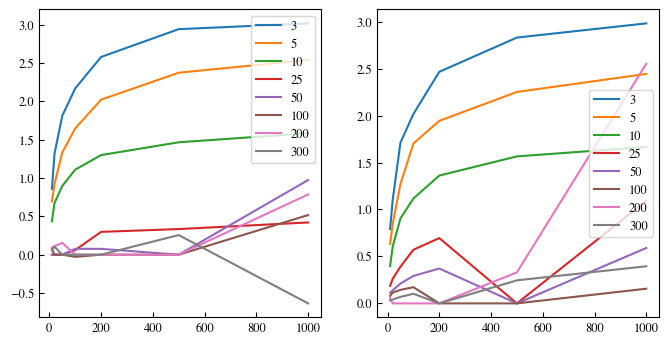

In [10]:
fig,ax = plt.subplots(ncols = len(embs),figsize=(4*len(embs),4))
for k in range(H.shape[0]):
    for i,h in enumerate(H[k]):
        ax[k].plot(nc_list,h,label=Klist[i])
    ax[k].legend()

## Optimize the value of tau

In [9]:
for emb in embs:
    emb.make_embedding(K=10)
    emb.make_cluster(n_clusters=200)

#mkvs = list()
#for emb in embs:
#    mkvs.append(MarkovFromEmbedding(emb,tau=1))

In [12]:
tau_list = [1,2,3,4,5,6,7,8,9,10,15,20,25,50,100]
eig_vals_10 = list()
l_eig_vals_10 = list()
entropies_rates = list()
timescales = list()
for tau in tau_list:
    mkvs = list()
    for emb in embs:
        mkvs.append(MarkovFromEmbedding(emb,tau=tau))
    eig_val_10,l_eig_val_10,entropy_rate,timescale = list(),list(),list(),list()
    for mkv in mkvs:
        mkv.compute_spectrum()
        eig_val_10.append(mkv.eigvals[-10:])
        l_eig_val_10.append(mkv.l_eigvals[-10:])
        entropy_rate.append(mkv.compute_entropy_rate())
        timescale.append(mkv.implied_timescales(tau=tau))
    eig_vals_10.append(eig_val_10)
    l_eig_vals_10.append(l_eig_val_10)
    entropies_rates.append(entropy_rate)
    timescales.append(timescale)
eig_vals_10 = np.array(eig_vals_10)
l_eig_vals_10 = np.array(l_eig_vals_10)
entropies_rates = np.array(entropies_rates)
timescales = np.array(timescales)

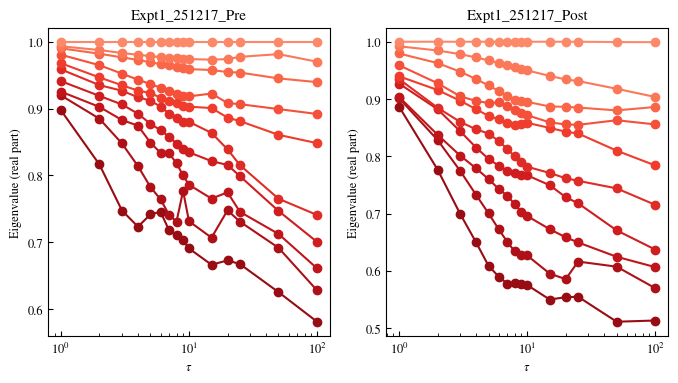

In [13]:
fig,ax = plt.subplots(ncols=embs.__len__(),nrows=1,figsize=(4*len(embs),4))
for i in range(eig_vals_10.shape[2]):
    # Plot    
    for j in range(eig_vals_10.shape[1]):
        ax[j].plot(tau_list, eig_vals_10[:,j,i],marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])    
        ax[j].set_xlabel("τ")
        ax[j].set_ylabel("Eigenvalue (real part)")
        ax[j].set_title(xml_files[j])
        ax[j].set_xscale('log')
        ax[j].set_xlabel(r'$\tau$')


(0.0, 1000.0)

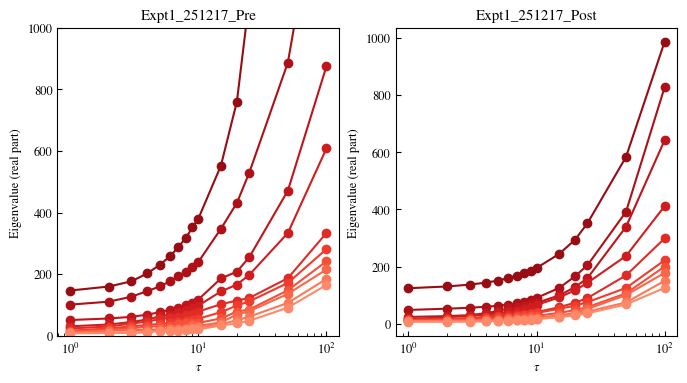

In [14]:
fig,ax = plt.subplots(ncols=len(embs),nrows=1,figsize=(len(embs)*4,4))
for i in range(10):
    # Plot    
    for j in range(timescales.shape[1]):
        ax[j].plot(tau_list, timescales[:,j,i],marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])    
        ax[j].set_xlabel("τ")
        ax[j].set_ylabel("Eigenvalue (real part)")
        ax[j].set_title(xml_files[j])
        ax[j].set_xscale('log')
        ax[j].set_xlabel(r'$\tau$')        
ax[0].set_ylim(0,10**3)



In [15]:
red_pts = list()
for emb in embs:
    pts,_ = emb.fit_umap(with_cluster_centers=False)
    red_pts.append(pts)

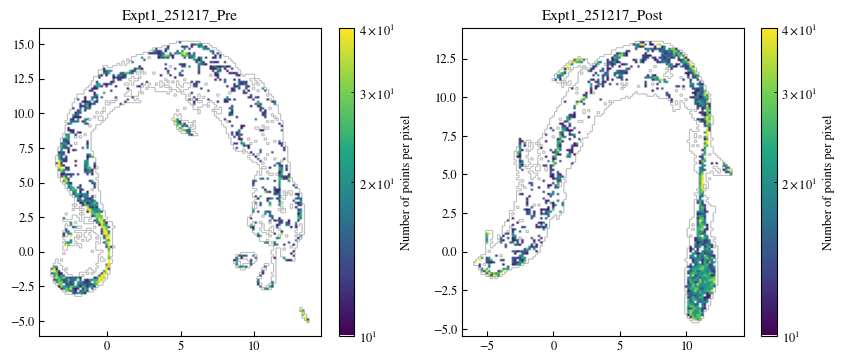

In [17]:
fig,ax = plt.subplots(nrows=1,ncols=len(embs),figsize=(len(embs)*5,4),subplot_kw={'projection':'scatter_density'})
norms = [LogNorm(vmin =10 ,vmax=40),LogNorm(vmin = 10,vmax=40)]
dpis = [50,50]
for i in range(len(embs)):
    src.viz.use_mpl_scatter_density(fig,red_pts[i][:,0],red_pts[i][:,1],ax=ax[i],dpi=dpis[i],norm=norms[i])
    src.viz.zoom_out(ax[i],1.1)
    ax[i].set_title(xml_files[i])

No meaningful split found (max min-metastability <= 0). Treating partition as final.


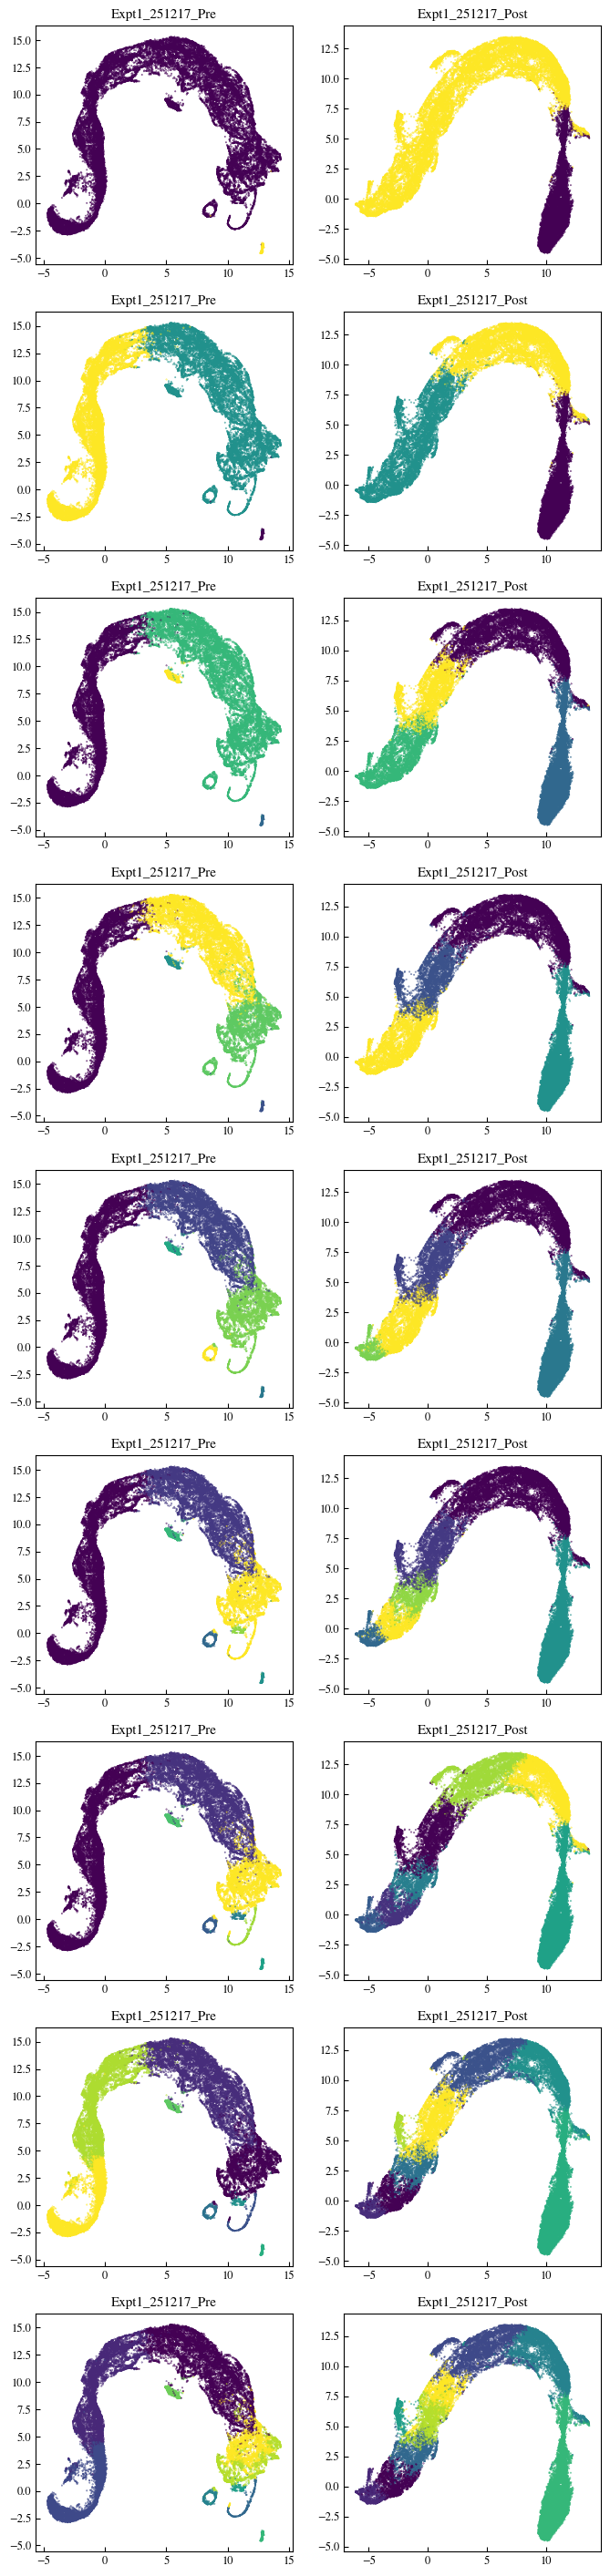

In [ ]:
n_partitions = [2,3,4,5,6,7,8,9,10]
fig,ax = plt.subplots(ncols=len(embs),nrows=len(n_partitions),figsize=(4*len(embs),4*len(n_partitions)))
for j in range(len(n_partitions)):
    n_partition= n_partitions[j]
    mkvs = list()
    for emb in embs:
        mkvs.append(MarkovFromEmbedding(emb,tau=3))
    partitions = list()
    for i in range(len(mkvs)):
        partitions.append(mkvs[i].recursive_partition(n_partition))
    clust_to_partitions = [[0 for _ in range(embs[i].n_clusters)] for i in range(len(embs))]

    for i in range(len(embs)):
        for partition_idx, cluster_ids in enumerate(partitions[i]):
            for id in cluster_ids:
                clust_to_partitions[i][id] = partition_idx
    clust_to_partitions = ak.Array(clust_to_partitions)


    for i in range(len(embs)):
        ax[j,i].scatter(red_pts[i][:,0],red_pts[i][:,1],s=0.1,c = clust_to_partitions[i][embs[i].labels])
        ax[j,i].set_title(xml_files[i])

In [ ]:
# store the embedding and markov inside a hdf5 file
output_filename = '../../data/choano/interim/nested_data.h5'

with h5py.File(output_filename, 'w') as hf:
    for i in range(len(xml_files)):
        name = xml_files[i]
        # Create a group for this specific 'name' to keep things organized
        grp = hf.create_group(name)

        # Save to HDF5 group with compression (optional but recommended)
        grp.create_dataset('umap_points', data=red_pts[i], compression="gzip")
        grp.create_dataset('color', data=clust_to_partitions[i][embs[i].labels], compression="gzip")

        emb_str = pickle.dumps(embs[i])
        grp.create_dataset('embedding', data=np.void(emb_str))

        mkv_str = pickle.dumps(mkvs[i])
        grp.create_dataset('markov', data=np.void(mkv_str))

print(f"Successfully packed data into {output_filename}")

Successfully packed data into ../../data/choano/interim/nested_data.h5


In [7]:
import awkward as ak
import importlib
import src.cluster
importlib.reload(src.cluster)
from src.cluster import Cluster
from scipy.special import entr

In [10]:
nc_com_list = [10,20,30,40,50,60,70,80,90,100,200,500,1000]
H_mix = list()
for nc in nc_com_list:
    clt = Cluster(nc)
    clt.add_embedding(embs[0])
    clt.add_embedding(embs[1])
    clt.set_shape_and_flatten()
    clt.clusterize()
    prop = clt.compute_proportions()
    H_mix.append((np.sum(entr(prop),axis=1)))
H_mix = ak.Array(H_mix)

In [ ]:
len(H_mix[9])

100

1000


Text(0, 0.5, 'mixing entropy of the clusters')

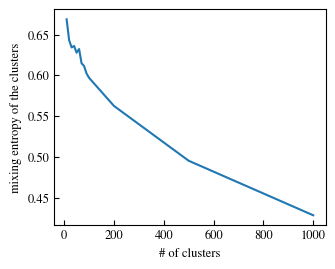

In [ ]:
plt.plot(nc_com_list,ak.mean(H_mix,axis=1))
print(nc_com_list[np.argmin(ak.mean(H_mix,axis=1))])
plt.xlabel('# of clusters')
plt.ylabel('mixing entropy of the clusters')

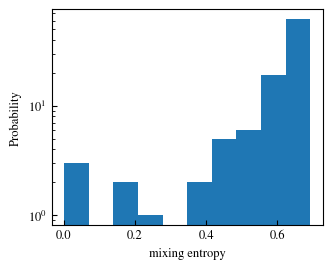

In [ ]:
plt.hist(H_mix[9])
plt.xlabel('mixing entropy')
plt.ylabel('Probability')
plt.yscale('log')

In [11]:
clt = Cluster(100)
clt.add_embedding(embs[0])
clt.add_embedding(embs[1])
clt.set_shape_and_flatten()
clt.clusterize()


In [12]:
mmkv = MultiMarkov(clt)

In [13]:
h_list = np.sum(entr(clt.compute_proportions()),axis=1) # compute the mixing entropy of every cluster
partitions = list()
n_partition = 5
hmin = 10**-10
reduced_systems = list()
for i in range(mmkv.__len__()):
    print()
    # add a loop to isolate the empty clusters
    keep = True
    isolated =list() # store the isolated clusters
    reduced_system = np.arange(mmkv[i].n_clusters) # start by considering every cluster
    while keep:
        partition = mmkv[i].recursive_partition(2,reduced_system = reduced_system)
        for part in partition:
            if all(h_list[part] <=hmin):
                keep = True
                for val in part:
                    reduced_system = reduced_system[~np.isin(reduced_system, part)]
                break
            keep = False
    reduced_systems.append(reduced_system)


In [14]:
partitions= list()
for i in range(len(mmkv)):
    partitions.append(mmkv[i].recursive_partition(3,reduced_system = reduced_systems[i]))

In [15]:
clt.fit_umap(with_cluster_centers=False)

In [19]:
len(ak.flatten(clt.reduced_pts[0]))

33498

In [20]:
# store the embedding and markov inside a hdf5 file
output_filename = '../../data/choano/interim/nested_multi_embs.h5'

with h5py.File(output_filename, 'w') as hf:
    for i in range(len(xml_files)):
        name = xml_files[i]
        # Create a group for this specific 'name' to keep things organized
        grp = hf.create_group(name)

        # Save to HDF5 group with compression (optional but recommended)
        grp.create_dataset('umap_points', data=ak.flatten(clt.reduced_pts[i]), compression="gzip")
        grp.create_dataset('color', data=H_mix[9][ak.flatten(clt.labels[i])], compression="gzip")

        emb_str = pickle.dumps(clt.embs[i])
        grp.create_dataset('embedding', data=np.void(emb_str))

        mkv_str = pickle.dumps(mmkv[i])
        grp.create_dataset('markov', data=np.void(mkv_str))

print(f"Successfully packed data into {output_filename}")

Successfully packed data into ../../data/choano/interim/nested_multi_embs.h5


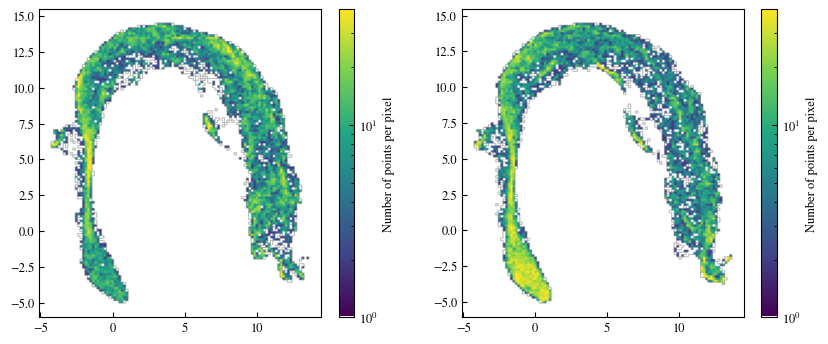

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=len(embs),figsize=(len(embs)*5,4),subplot_kw={'projection':'scatter_density'})
norms = [LogNorm(vmin =1 ,vmax=40),LogNorm(vmin = 1,vmax=40)]
dpis = [50,50]
for i in range(len(embs)):
    src.viz.use_mpl_scatter_density(fig,ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],ax=ax[i],dpi=dpis[i],norm=norms[i])
    src.viz.zoom_out(ax[i],1.1)

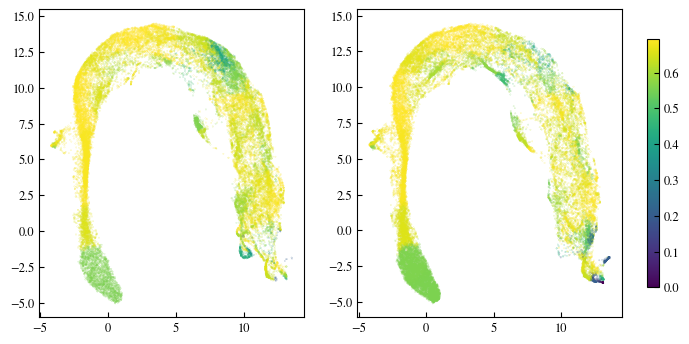

In [ ]:
# 1. Calculate the color data for both plots
c0 = H_mix[9][ak.flatten(clt.labels[0])]
c1 = H_mix[9][ak.flatten(clt.labels[1])]

# 2. Find the global min and max across both sets
# Using np.nanmin/max is safer if there are potential NaNs
vmin = min(np.min(c0), np.min(c1))
vmax = max(np.max(c0), np.max(c1))

fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

# 3. Apply vmin and vmax to both plots
im0 = ax[0].scatter(
    ak.flatten(clt.reduced_pts[0])[:,0], 
    ak.flatten(clt.reduced_pts[0])[:,1], 
    s=0.01, alpha=1., c=c0, vmin=vmin, vmax=vmax
)

im1 = ax[1].scatter(
    ak.flatten(clt.reduced_pts[1])[:,0], 
    ak.flatten(clt.reduced_pts[1])[:,1], 
    s=0.01, alpha=1., c=c1, vmin=vmin, vmax=vmax
)

# Optional: Add a single colorbar for both plots
fig.colorbar(im1, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

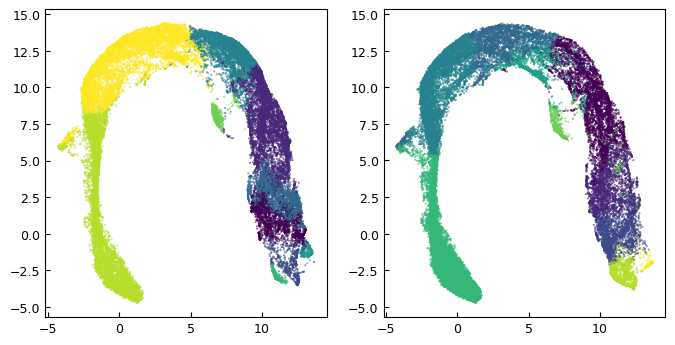

In [ ]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = clust_to_partitions[i][embs[i].labels])

In [ ]:
cluster_to_partition = np.zeros((2,clt.n_clusters), dtype=int)

for i in range(2):
    for partition_idx, cluster_ids in enumerate(partitions[i]):
        cluster_to_partition[i][cluster_ids] = partition_idx

In [ ]:
partition_labels = list()
for i in range(2):
    partition_labels.append(ak.Array([cluster_to_partition[i,labels] for labels in clt.labels[i]]))

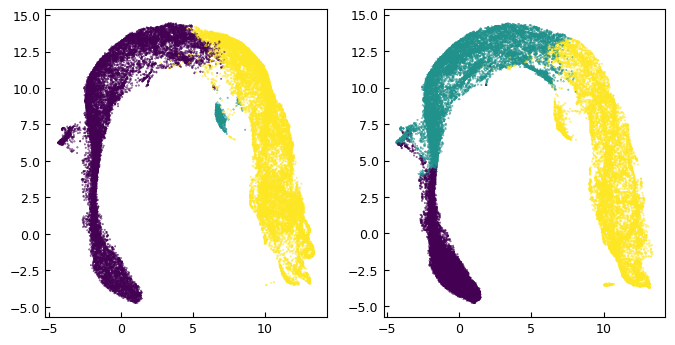

In [ ]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = ak.flatten(partition_labels[i]))

In [ ]:
# save the files to investigate with the dash app
folder = "../../data/Algoriphagus/"
parquet_files = ["Expt1_251217_Pre_umap.parquet", "Expt1_251217_Post_umap.parquet"]
color_files = ['coarse_grained_Pre.parquet','coarse_grained_Post.parquet']
for i in range(len(clt.reduced_pts)):
    ak.to_parquet(clt.reduced_pts[i],folder+parquet_files[i])
    ak.to_parquet(partition_labels[i],folder + color_files[i])



In [ ]:
import pickle

for emb in embs:
    with open(folder, 'wb') as f:
    pickle.dump(clt, f)